In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import sys
import argparse
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


In [2]:
dataset = pd.read_csv('/Users/maheshg/Dropbox/Sample Datasets Kaggle/news.csv')

In [4]:
dataset.head()

,text,label
0,Gere faults Trump for blurring meaning of 'ref...,1
1,German parties start to find common ground in ...,1
2,Senate Democratic leader says Attorney General...,1
3,"Tennis: Kyrgios fined $10,000 for Shanghai wal...",1
4,Trump Threw Mar-A-Lago Fundraiser For Woman A...,0


In [6]:
dataset.size

91514

In [7]:
dataset.shape

(45757, 2)

Accuracy: 0.9674388111888111
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      4572
           1       0.96      0.97      0.97      4580

    accuracy                           0.97      9152
   macro avg       0.97      0.97      0.97      9152
weighted avg       0.97      0.97      0.97      9152



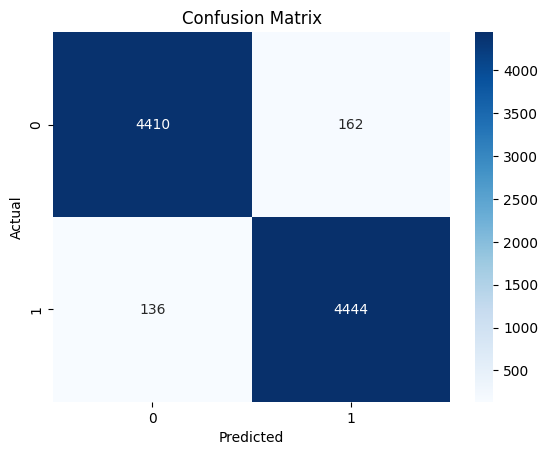

Top positive features: ['said', 'reuters', 'washington reuters', 'washington', 'wednesday', 'president donald', 'tuesday', 'thursday', 'monday', 'republican', 'friday', 'reuters president', 'minister', 'year', 'presidential', 'said statement', 'spokesman', 'told', 'statement', 'democratic']
Top negative features: ['video', 'just', 'hillary', 'featured image', 'featured', 'gop', 'com', 'watch', 'image', 'america', 'like', 'obama', 'fact', 'isis', 'president trump', 'getty', 'read', 'president obama', 'getty images', 'american']


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# split dataset into training and test sets
X = dataset['text']
y = dataset['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# convert raw text to TF-IDF features
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.8, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# train a logistic regression classifier
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)

# evaluate the model
y_pred = model.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# display confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# inspect top features
feature_names = vectorizer.get_feature_names_out()
top_positive = sorted(zip(model.coef_[0], feature_names), reverse=True)[:20]
top_negative = sorted(zip(model.coef_[0], feature_names))[:20]
print("Top positive features:", [feature for _, feature in top_positive])
print("Top negative features:", [feature for _, feature in top_negative])